# CNPI Hybrid RAG — Graph Notebook

এই notebook-এ `graph.py` থেকে গ্রাফ import করে test করা হয়।

> **Note:** Jupyter Notebook-এ `__file__` নেই, তাই প্রথম cell-এ `sys.path` manually সেট করা হয়।

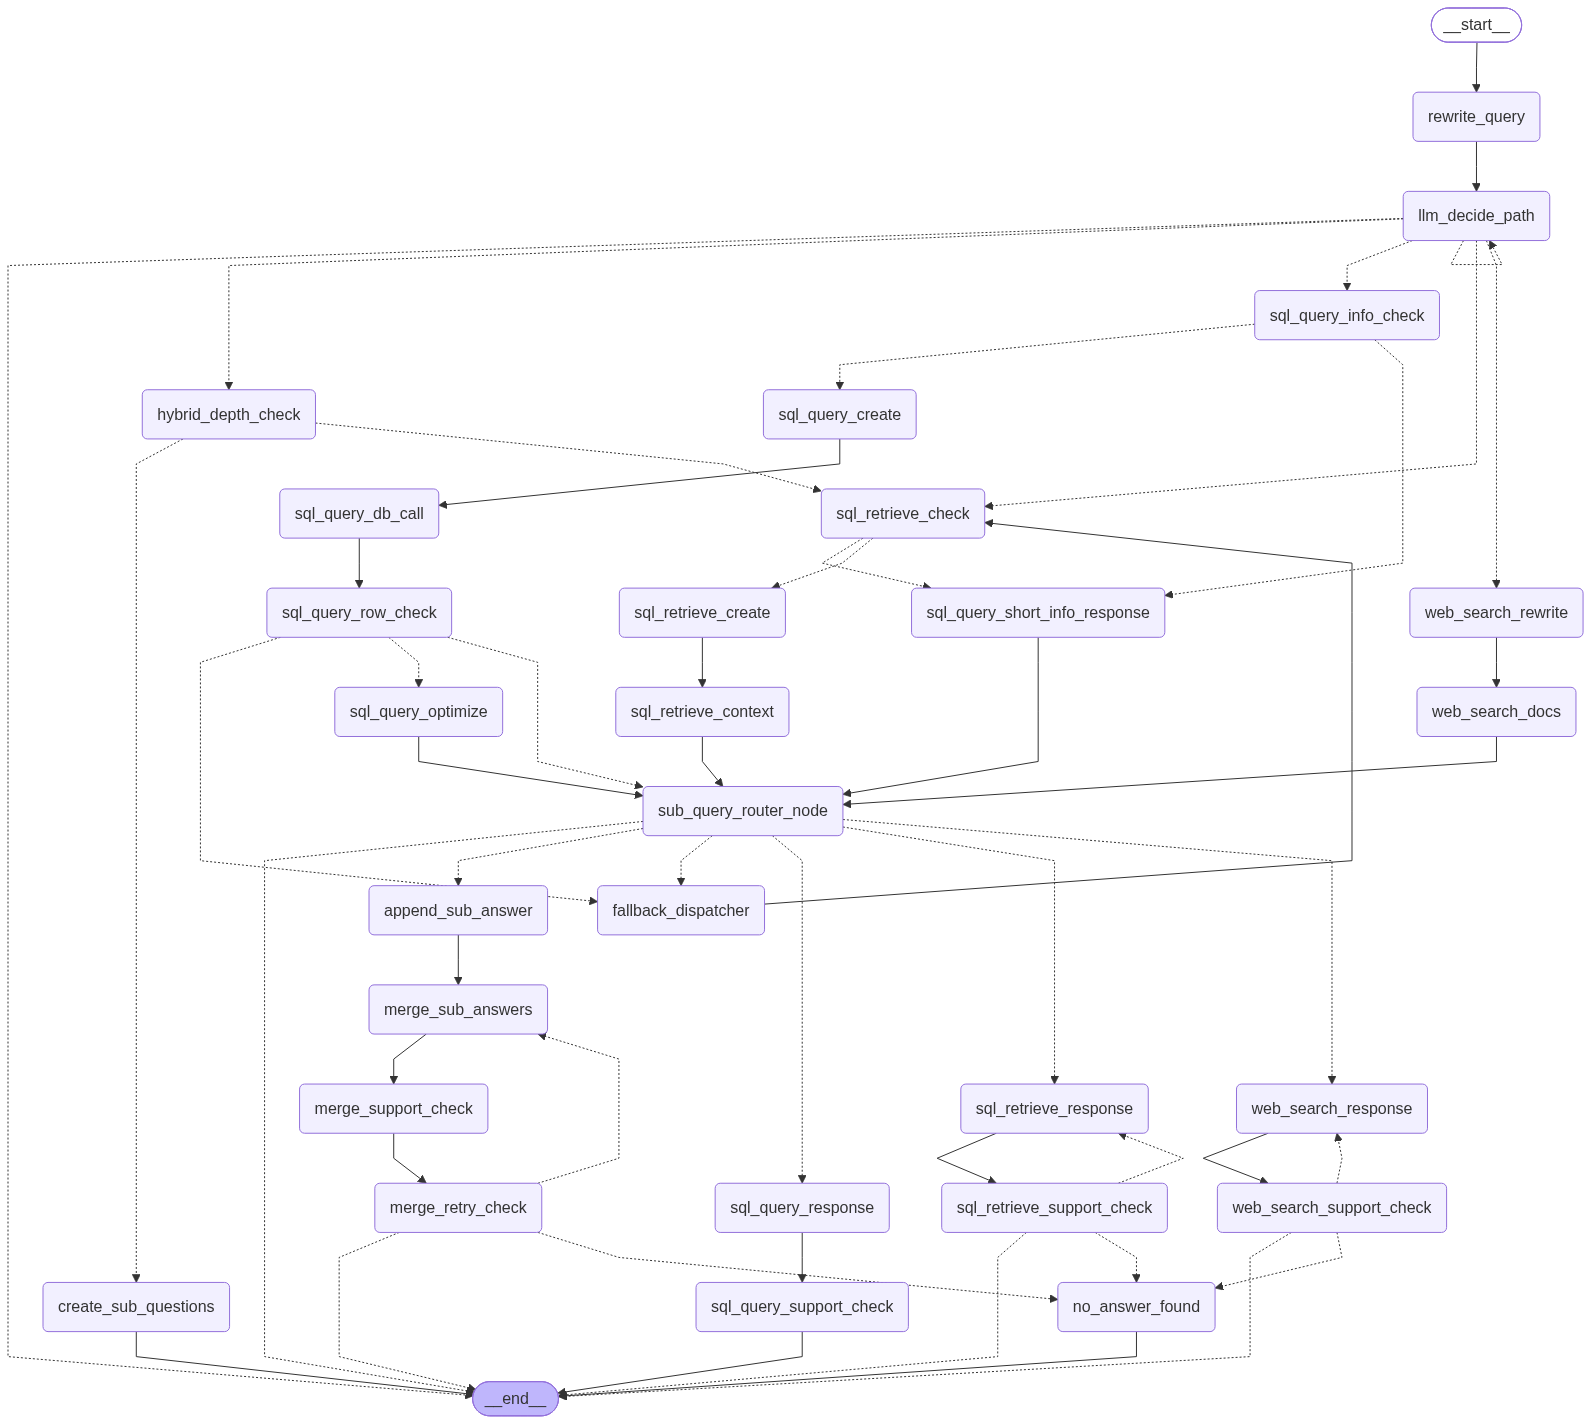

In [6]:
"""
Graph Builder - Phase 1, 2, 3, 4 & 5 (Complete)
==================================================

This file builds the COMPLETE LangGraph for the CNPI RAG system:
- Phase 1 (Router)         : rewrite_query → llm_decide_path → confidence_score check
- Phase 2 (SQL Query)      : info_check → create → db_call → row_check → response → support_check
- Phase 3 (SQL Retrieve)   : check → create → context → response → support_check
- Phase 4 (Web Search)     : rewrite → docs → response → support_check
- Phase 5 (Hybrid/Sub-Q)   : depth_check → create_sub_questions → dispatch (Send API)
                             → [parallel paths] → append_sub_answer → merge → support → retry_check

Key Phase 5 design (LangGraph Send API map-reduce):
    dispatch_sub_queries returns a list[Send] targeting `rewrite_query`.
    Each Send carries an isolated sub-state with is_sub_query_call=True.
    When a path support_check finishes, is_sub_query_call=True routes to
    append_sub_answer instead of END.
    append_sub_answer uses hybrid.sub_query_ans (operator.add reducer) to
    fan-in all parallel results, then routes to merge_sub_answers when
    sub_ans_count == total_sub_q.
"""

import sys
from pathlib import Path
from typing import Literal

# Ensure plan/ is on the path so that `from state import RAGState` works
# Note: __file__ is not defined in Jupyter notebooks, so we use a fallback.
try:
    _project_root = Path(__file__).resolve().parent
except NameError:
    # Running inside a Jupyter / IPython kernel — use the notebook's CWD
    import os
    _project_root = Path(os.getcwd()).resolve()

_plan_root = _project_root.parent / "plan"
for _p in [str(_plan_root), str(_project_root)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from langgraph.graph import StateGraph, END

# Import state from canonical source
from state import RAGState, MAX_RETRIES, MAX_HYBRID_DEPTH

# Import Phase 1 nodes
from nodes.entry import rewrite_query_node
from nodes.router import llm_decide_path_node

# Import Phase 2 nodes (SQL Query path)
from nodes.sql_query_info_check import sql_query_info_check_node
from nodes.sql_query_create import sql_query_create_node
from nodes.sql_query_db_call import sql_query_db_call_node
from nodes.sql_query_row_check import sql_query_row_check_node
from nodes.sql_query_optimize import sql_query_optimize_node
from nodes.sql_query_response import sql_query_response_node
from nodes.sql_query_support_check import sql_query_support_check_node
from nodes.sql_query_short_info_response import sql_query_short_info_response_node
from nodes.fallback_dispatcher import fallback_dispatcher_node

# Import Phase 3 nodes (SQL Retrieve path)
from nodes.sql_retrieve_check import sql_retrieve_check_node
from nodes.sql_retrieve_create import sql_retrieve_create_node
from nodes.sql_retrieve_context import sql_retrieve_context_node
from nodes.sql_retrieve_response import sql_retrieve_response_node
from nodes.sql_retrieve_support_check import sql_retrieve_support_check_node
from nodes.no_answer_found import no_answer_found_node

# Import Phase 4 nodes (Web Search path)
from nodes.web_search_rewrite import web_search_rewrite_node
from nodes.web_search_docs import web_search_docs_node
from nodes.web_search_response import web_search_response_node
from nodes.web_search_support_check import web_search_support_check_node

# Import Phase 5 nodes (Hybrid Sub-Query path)
from nodes.hybrid_depth_check import hybrid_depth_check_node
from nodes.hybrid_create_sub_questions import create_sub_questions_node
from nodes.hybrid_dispatch_sub_queries import dispatch_sub_queries_node
from nodes.hybrid_append_sub_answer import append_sub_answer_node
from nodes.hybrid_merge_sub_answers import merge_sub_answers_node
from nodes.hybrid_merge_support_check import merge_support_check_node
from nodes.hybrid_merge_retry_check import merge_retry_check_node


def sub_query_router_node(state: RAGState) -> dict:
    """Pass-through node to make the sub-query exit routing visible in the graph."""
    return state


# =============================================================================
# Graph Builder
# =============================================================================

def build_graph():
    """
    Build the COMPLETE graph for the CNPI RAG system (Phase 1–5).

    Phase 5 (Hybrid) uses LangGraph Send API for parallel sub-query execution:
        dispatch_sub_queries → [Send("rewrite_query", sub_state) × N]
        → each branch traverses its own path (SQL Query / SQL Retrieve / Web Search)
        → converges at append_sub_answer (fan-in via operator.add reducer)
        → merge_sub_answers → merge_support_check → merge_retry_check → END

    Depth guard:
        hybrid_depth_check confirms depth < MAX_HYBRID_DEPTH before decomposing.
        Sub-queries are never allowed to spawn further Hybrid paths.
    """
    graph = StateGraph(RAGState)

    # -------------------------------------------------------------------------
    # Phase 1 nodes
    # -------------------------------------------------------------------------
    graph.add_node("rewrite_query", rewrite_query_node)
    graph.add_node("llm_decide_path", llm_decide_path_node)

    # -------------------------------------------------------------------------
    # Phase 2 — SQL Query path nodes
    # -------------------------------------------------------------------------
    graph.add_node("sql_query_info_check", sql_query_info_check_node)
    graph.add_node("sql_query_short_info_response", sql_query_short_info_response_node)
    graph.add_node("sql_query_create", sql_query_create_node)
    graph.add_node("sql_query_db_call", sql_query_db_call_node)
    graph.add_node("sql_query_row_check", sql_query_row_check_node)       # ← only checks count
    graph.add_node("sql_query_optimize", sql_query_optimize_node)         # ← only for row > 1
    graph.add_node("fallback_dispatcher", fallback_dispatcher_node)
    graph.add_node("sql_query_response", sql_query_response_node)
    graph.add_node("sql_query_support_check", sql_query_support_check_node)

    # -------------------------------------------------------------------------
    # Phase 3 — SQL Retrieve path nodes
    # -------------------------------------------------------------------------
    graph.add_node("sql_retrieve_check", sql_retrieve_check_node)
    graph.add_node("sql_retrieve_create", sql_retrieve_create_node)
    graph.add_node("sql_retrieve_context", sql_retrieve_context_node)
    graph.add_node("sql_retrieve_response", sql_retrieve_response_node)
    graph.add_node("sql_retrieve_support_check", sql_retrieve_support_check_node)

    # -------------------------------------------------------------------------
    # Phase 4 — Web Search path nodes
    # -------------------------------------------------------------------------
    graph.add_node("web_search_rewrite", web_search_rewrite_node)
    graph.add_node("web_search_docs", web_search_docs_node)
    graph.add_node("web_search_response", web_search_response_node)
    graph.add_node("web_search_support_check", web_search_support_check_node)
    graph.add_node("no_answer_found", no_answer_found_node)

    # -------------------------------------------------------------------------
    # Phase 5 — Hybrid Sub-Query path nodes
    # -------------------------------------------------------------------------
    graph.add_node("hybrid_depth_check", hybrid_depth_check_node)
    graph.add_node("create_sub_questions", create_sub_questions_node)
    # dispatch_sub_queries is a conditional edge, not a node.
    graph.add_node("sub_query_router_node", sub_query_router_node)
    graph.add_node("append_sub_answer", append_sub_answer_node)
    graph.add_node("merge_sub_answers", merge_sub_answers_node)
    graph.add_node("merge_support_check", merge_support_check_node)
    graph.add_node("merge_retry_check", merge_retry_check_node)

    # -------------------------------------------------------------------------
    # Phase 1 edges
    # -------------------------------------------------------------------------
    graph.add_edge("rewrite_query", "llm_decide_path")

    # ---- Router: low confidence → retry | high confidence → route by path ----
    def _route_after_decision(state: RAGState) -> Literal[
        "llm_decide_path",
        "sql_query_info_check",
        "sql_retrieve_check",
        "web_search_rewrite",
        "hybrid_depth_check",
        "__end__",
    ]:
        """Route to the right path entry node based on confidence + decided_path."""
        confidence_score = state.get("confidence_score", 0.0)
        if confidence_score < 0.7:
            return "hybrid_depth_check"

        decided_path = state.get("decided_path", "sql_retrieve")
        if decided_path == "sql_query":
            return "sql_query_info_check"
        elif decided_path == "sql_retrieve":
            return "sql_retrieve_check"
        elif decided_path == "web_search":
            return "web_search_rewrite"
        elif decided_path == "hybrid":
            return "hybrid_depth_check"           # Phase 5 entry
        else:
            return "__end__"

    graph.add_conditional_edges(
        "llm_decide_path",
        _route_after_decision,
        {
            "llm_decide_path": "llm_decide_path",
            "sql_query_info_check": "sql_query_info_check",
            "sql_retrieve_check": "sql_retrieve_check",
            "web_search_rewrite": "web_search_rewrite",
            "hybrid_depth_check": "hybrid_depth_check",   # Phase 5
            "__end__": END,
        },
    )

    # -------------------------------------------------------------------------
    # Phase 2 — SQL Query path edges
    # -------------------------------------------------------------------------

    # ---- FIX 2: short_info / not_possible early exit ----
    def _route_after_info_check(state: RAGState) -> Literal[
        "sql_query_short_info_response", "sql_query_create"
    ]:
        """
        If info_check flagged short_info=True OR not_possible=True,
        route to the clarification response node and exit.
        Otherwise continue to SQL query creation.
        (Matches diagram: short_info / sql_not_possible branch)
        """
        sql_query_state = state.get("sql_query", {})
        short_info = sql_query_state.get("short_info", False)
        not_possible = sql_query_state.get("not_possible", False)
        if short_info or not_possible:
            return "sql_query_short_info_response"
        return "sql_query_create"

    graph.add_conditional_edges(
        "sql_query_info_check",
        _route_after_info_check,
        {
            "sql_query_short_info_response": "sql_query_short_info_response",
            "sql_query_create": "sql_query_create",
        },
    )

    # short_info_response goes to sub_query_router_node to handle sub_query exit or END gracefully
    graph.add_edge("sql_query_short_info_response", "sub_query_router_node")
    graph.add_edge("sql_query_create", "sql_query_db_call")
    graph.add_edge("sql_query_db_call", "sql_query_row_check")

    # Row-count routing:
    #   row = 0  → fallback_dispatcher (no data)
    #   row = 1  → sub_query_router_node (single result, ready for LLM)
    #   row > 1  → sql_query_optimize (merge multi-row context first)
    def _route_after_row_check(state: RAGState) -> Literal[
        "fallback_dispatcher", "sub_query_router_node", "sql_query_optimize"
    ]:
        """Route based on row_count from DB:
            0  → fallback to SQL Retrieve path
            1  → single result, straight to router
            >1 → multiple results, optimise context first
        """
        row_count = state.get("sql_query", {}).get("row_count", 0)
        if row_count == 0:
            return "fallback_dispatcher"
        if row_count == 1:
            return "sub_query_router_node"   # single row, skip optimise step
        return "sql_query_optimize"           # multiple rows, merge first

    graph.add_conditional_edges(
        "sql_query_row_check",
        _route_after_row_check,
        {
            "fallback_dispatcher": "fallback_dispatcher",
            "sub_query_router_node": "sub_query_router_node",
            "sql_query_optimize": "sql_query_optimize",
        },
    )

    # optimize → sub_query_router_node (always, after multi-row merge)
    graph.add_edge("sql_query_optimize", "sub_query_router_node")

    # Bridge between fallback dispatcher and real SQL Retrieve
    graph.add_edge("fallback_dispatcher", "sql_retrieve_check")

    graph.add_edge("sql_query_response", "sql_query_support_check")

    # SQL Query support_check → directly END (sub_queries never reach here)
    graph.add_edge("sql_query_support_check", END)

    # -------------------------------------------------------------------------
    # Phase 3 — SQL Retrieve path edges
    # -------------------------------------------------------------------------

    # check → (more_info needed? short_info_response : create)
    def _route_retrieve_check(state: RAGState) -> Literal[
        "sql_retrieve_create", "sql_query_short_info_response"
    ]:
        """If the query is unsuitable / needs more info, route to short_info_response."""
        sql_retrieve_state = state.get("sql_retrieve", {})
        need_more_info = sql_retrieve_state.get("need_more_info", False)
        return "sql_query_short_info_response" if need_more_info else "sql_retrieve_create"

    graph.add_conditional_edges(
        "sql_retrieve_check",
        _route_retrieve_check,
        {
            "sql_retrieve_create": "sql_retrieve_create",
            "sql_query_short_info_response": "sql_query_short_info_response",
        },
    )

    graph.add_edge("sql_retrieve_create", "sql_retrieve_context")

    # context → sub_query_router_node (unconditional solid edge)
    # Router will handle: sub_query→append, context_found→sql_retrieve_response, no_context→END
    graph.add_edge("sql_retrieve_context", "sub_query_router_node")

    graph.add_edge("sql_retrieve_response", "sql_retrieve_support_check")

    # SQL Retrieve support_check: retry → sql_retrieve_RESPONSE (not create), max MAX_RETRIES
    def _route_retrieve_support_check(state: RAGState) -> Literal[
        "__end__", "sql_retrieve_response", "no_answer_found"
    ]:
        """If support check returns false (answer not good), retry the LLM response node.

        Retries sql_retrieve_response directly (same context, fresh LLM generation).
        Maximum MAX_RETRIES attempts before giving up and going to no_answer_found.
        """
        sql_retrieve_state = state.get("sql_retrieve", {})
        retry_count = sql_retrieve_state.get("retry_count", 0)
        supported = sql_retrieve_state.get("supported", True)   # set by support_check node

        if supported:
            return "__end__"
        
        if retry_count < MAX_RETRIES:
            return "sql_retrieve_response"   # retry LLM with same context

        return "no_answer_found"   # retries exhausted or no_support found

    graph.add_conditional_edges(
        "sql_retrieve_support_check",
        _route_retrieve_support_check,
        {
            "__end__": END,
            "sql_retrieve_response": "sql_retrieve_response",
            "no_answer_found": "no_answer_found",
        },
    )

    # -------------------------------------------------------------------------
    # Phase 4 — Web Search path edges
    # -------------------------------------------------------------------------

    # rewrite → docs (always)
    graph.add_edge("web_search_rewrite", "web_search_docs")

    # docs → sub_query_router_node (unconditional solid edge)
    # Router will handle: sub_query→append, context→web_search_response, no_context→END
    graph.add_edge("web_search_docs", "sub_query_router_node")

    # response → support_check (always)
    graph.add_edge("web_search_response", "web_search_support_check")

    # Web Search support_check: retry logic only — sub_queries never reach here
    def _route_web_support_check(state: RAGState) -> Literal[
        "__end__", "web_search_response", "no_answer_found"
    ]:
        """Retry if answer not found and retries remain; otherwise go to no_answer_found."""
        answer_status = state.get("answer_status", "pending")
        if answer_status == "found":
            return "__end__"

        web_search_state = state.get("web_search", {})
        retry_count = web_search_state.get("retry_count", 0)
        if retry_count < MAX_RETRIES:
            return "web_search_response"

        return "no_answer_found"

    graph.add_conditional_edges(
        "web_search_support_check",
        _route_web_support_check,
        {
            "__end__": END,
            "web_search_response": "web_search_response",
            "no_answer_found": "no_answer_found",
        },
    )

    # -------------------------------------------------------------------------
    # No Answer Found Node Edge
    # -------------------------------------------------------------------------
    graph.add_edge("no_answer_found", END)

    # =========================================================================
    # Phase 5 — Hybrid Sub-Query path edges
    # =========================================================================

    # ---- Depth check: depth < MAX_HYBRID_DEPTH → decompose, else → fallback ----
    def _route_after_depth_check(state: RAGState) -> Literal[
        "create_sub_questions", "sql_retrieve_check"
    ]:
        """Allow sub-query decomposition only at depth < MAX_HYBRID_DEPTH.

        depth was INCREMENTED by hybrid_depth_check_node; so after that node:
            depth == 1 (came from 0) → still within limit → decompose
            depth >= 2              → already nested    → fallback to sql_retrieve
        """
        hybrid_state = state.get("hybrid", {})
        depth: int = hybrid_state.get("depth", 1)
        if depth <= MAX_HYBRID_DEPTH:
            return "create_sub_questions"
        # Sub-query recursion guard: fall back to sql_retrieve
        return "sql_retrieve_check"

    graph.add_conditional_edges(
        "hybrid_depth_check",
        _route_after_depth_check,
        {
            "create_sub_questions": "create_sub_questions",
            "sql_retrieve_check": "sql_retrieve_check",
        },
    )

    # dispatch_sub_queries uses Send API — returns list[Send("rewrite_query", sub_state)]
    # LangGraph handles the fan-out automatically; each branch re-enters the full pipeline.
    # In LangGraph, nodes returning List[Send] must be used as conditional edges!
    graph.add_conditional_edges("create_sub_questions", dispatch_sub_queries_node)

    # ---- Central gateway: decides for ALL paths after context is collected ----
    def _route_sub_query_node(state: RAGState) -> Literal[
        "append_sub_answer",
        "sql_query_response",
        "sql_retrieve_response",
        "web_search_response",
        "fallback_dispatcher",
        "__end__",
    ]:
        """Single decision point between context collection and response generation.

        Sub-query branch (is_sub_query_call=True):
            → append_sub_answer  (always — context collected, skip LLM)

        Normal branch (is_sub_query_call=False), routed by decided_path:
            sql_query  : row_count > 0 → sql_query_response
                         row_count = 0 → fallback_dispatcher → sql_retrieve
            sql_retrieve: context_found → sql_retrieve_response
                          no context   → END
            web_search : context found → web_search_response
                         no context   → END
        """
        is_sub_query_call = state.get("is_sub_query_call", False)

        # Sub-query branches: collect context, skip LLM, fan-in
        if is_sub_query_call:
            return "append_sub_answer"

        # Normal query: route to the correct response LLM node
        decided_path = state.get("decided_path", "sql_retrieve")

        if decided_path == "sql_query":
            short_info = state.get("sql_query", {}).get("short_info", False)
            not_possible = state.get("sql_query", {}).get("not_possible", False)
            if short_info or not_possible:
                return "__end__"  # already answered with short info

            row_count = state.get("sql_query", {}).get("row_count", 0)
            if row_count == 0:
                return "fallback_dispatcher"   # 0 rows → cross-path to sql_retrieve
            return "sql_query_response"

        elif decided_path == "sql_retrieve":
            context_found = state.get("sql_retrieve", {}).get("context_found", False)
            return "sql_retrieve_response" if context_found else "__end__"

        elif decided_path == "web_search":
            context = state.get("web_search", {}).get("context", "").strip()
            return "web_search_response" if context else "__end__"

        return "__end__"

    graph.add_conditional_edges(
        "sub_query_router_node",
        _route_sub_query_node,
        {
            "append_sub_answer": "append_sub_answer",
            "sql_query_response": "sql_query_response",
            "sql_retrieve_response": "sql_retrieve_response",
            "web_search_response": "web_search_response",
            "fallback_dispatcher": "fallback_dispatcher",
            "__end__": END,
        }
    )

    # append_sub_answer → merge_sub_answers
    # LangGraph AUTOMATICALLY waits for all parallel branches to accumulate their
    # outputs into the 'sub_query_ans' list reducer before moving on to merge.
    # We do NOT need a manual while loop here!
    graph.add_edge("append_sub_answer", "merge_sub_answers")

    # merge_sub_answers → merge_support_check (always)
    graph.add_edge("merge_sub_answers", "merge_support_check")

    # merge_support_check → merge_retry_check (always)
    graph.add_edge("merge_support_check", "merge_retry_check")

    # merge_retry_check: found → END | retry → merge_sub_answers | exhausted → no_answer_found
    def _route_merge_retry_check(state: RAGState) -> Literal[
        "merge_sub_answers", "__end__", "no_answer_found"
    ]:
        """Retry merge if not yet supported and retries remain."""
        hybrid_state = state.get("hybrid", {})
        merge_retries: int = hybrid_state.get("merge_retries", 0)
        answer_status: str = state.get("answer_status", "not_found")

        if answer_status == "found":
            return "__end__"            # final answer accepted
        if merge_retries < MAX_RETRIES:
            return "merge_sub_answers"  # retry the LLM merge
        return "no_answer_found"                # exhausted

    graph.add_conditional_edges(
        "merge_retry_check",
        _route_merge_retry_check,
        {
            "merge_sub_answers": "merge_sub_answers",
            "__end__": END,
            "no_answer_found": "no_answer_found",
        },
    )

    # -------------------------------------------------------------------------
    # Entry point
    # -------------------------------------------------------------------------
    graph.set_entry_point("rewrite_query")

    return graph


# Build and export the final app
app = build_graph()
compiled = app.compile()
compiled


# =============================================================================
# Example Usage (for testing)
# =============================================================================

